In [224]:
#matplotlib widget
import numpy as np
# import matplotlib
# matplotlib.use('module://matplotlib_inline.backend_inline')  # ← remove or comment

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from mpl_toolkits import mplot3d

import jax.numpy as jnp  

import jaxopt  

import bernstein_coeff_order10_arbitinterval

# # from optim_uneven_2_fft_reduced_grad_old import optim_cem_uneven
from fn_stability_plot import optim_cem_uneven
# # from optim_uneven_2_fft_reduced_proj_grad import optim_cem_uneven
# from fn_stability_plot2 import optim_cem_uneven as optim_cem_uneven2

import time

import open3d as o3d

import jax
jax.config.update("jax_enable_x64", True)
from jax import jit, random, vmap, grad
from functools import partial

In [225]:

def rpy_to_rotation_matrix(roll, pitch, yaw):
        """Compute rotation matrix from intrinsic ZYX Euler angles in radians."""
        cr = jnp.cos(roll)
        sr = jnp.sin(roll)
        cp = jnp.cos(pitch)
        sp = jnp.sin(pitch)
        cy = jnp.cos(yaw)
        sy = jnp.sin(yaw)

        Rz = jnp.array([
            [cy, -sy, 0],
            [sy,  cy, 0],
            [ 0,   0, 1]
        ])

        Ry = jnp.array([
            [ cp, 0, sp],
            [  0, 1,  0],
            [-sp, 0, cp]
        ])

        Rx = jnp.array([
            [1,  0,   0],
            [0, cr, -sr],
            [0, sr,  cr]
        ])
        R = Rz @ Ry @ Rx  # Z * Y * X
        
        return R



In [226]:

@partial(jit)
def batch_cross_product(a, b):
    def single_cp(x, y):
        return jnp.array([
                x[1]*y[2] - x[2]*y[1],
                x[2]*y[0] - x[0]*y[2],
                x[0]*y[1] - x[1]*y[0]
        ])
    return vmap(single_cp)(a, b)

In [227]:
from jaxopt import OSQP 
#qp = OSQP(primal_infeasible_tol=1e-3, dual_infeasible_tol=1e-3, maxiter=10)
qp = OSQP()

def solve_qp_batch(surface_normals, surface_tractions, surface_normals_moment, surface_tractions_moment, weight, coeff_fric, slope):
    
    def solve_qp(surface_normals, surface_tractions, surface_normals_moment, surface_tractions_moment, weight, coeff_fric, slope):
        
    
        Q = jnp.eye(8)

        #Q = Q.at[4:8,4:8].set(0)
        
        # Equality constraints for force and moment balance
        A = jnp.zeros((6,8))
        A = A.at[:3, :4].set(surface_normals)
        A = A.at[:3, 4:8].set(surface_tractions)
        A = A.at[3:6, :4].set(surface_normals_moment)
        A = A.at[3:6, 4:8].set(surface_tractions_moment)
        b = jnp.array([0.0, 0.0, weight, 0.0, 0.0, 0.0]).reshape(6, 1)
        
        # Inequality constraints for friction cone
        # We need 8 constraints for 4 contact points (2 per contact point)
        G = jnp.zeros((12, 8))
        h = jnp.zeros((12, 1))
        c = jnp.zeros((8, 1))

        a = jnp.zeros((8, 1))
        a = a.at[:4,:].set(weight/(4*jnp.cos(0)))

        c = - Q @ a


        for i in range(4):
            # # First friction cone constraint: tangential_force_i ≤ μ * normal_force_i
            # G = G.at[i, i].set(-coeff_fric)  # Coefficient for normal force
            # G = G.at[i, i+4].set(1)          # Coefficient for tangential force
            
            # # Second friction cone constraint: -tangential_force_i ≤ μ * normal_force_i
            # G = G.at[i+4, i].set(-coeff_fric)  # Coefficient for normal force
            # G = G.at[i+4, i+4].set(-1)         # Coefficient for tangential force
            
            # Non-negativity constraint for normal forces: normal_force_i ≥ 0
            G = G.at[i+8, i].set(-1)         # Ensure normal forces are positive
        
        qp_sol = qp.run(params_obj=(Q, c), params_eq=(A, b), params_ineq=(G, h)).params

        return qp_sol.primal
    
    return vmap(solve_qp, in_axes=(0, 0, 0, 0, None, None, None))(surface_normals, surface_tractions, 
                                                            surface_normals_moment, surface_tractions_moment,
                                                            weight, coeff_fric, slope)

In [228]:

t_fin = 20
num = 100
t = t_fin/num

tot_time = np.linspace(0, t_fin, num)
tot_time = tot_time
tot_time_copy = tot_time.reshape(num, 1)


P, Pdot, Pddot = bernstein_coeff_order10_arbitinterval.bernstein_coeff_order10_new(10, tot_time_copy[0], tot_time_copy[-1], tot_time_copy)



In [229]:
def get_local_patch(input_points, query_point, patch_lim):
    """
    Gets the local point cloud patch of radius patch_lim from the input terrain point cloud
    input_points = (n x 3)
    query_point = (3,)
    lim = patch radius
    """
    dists = jnp.linalg.norm(input_points[:, :2] - query_point[:2], axis=1)
    local_xyz = input_points[dists<=patch_lim]

    return local_xyz


In [230]:

def get_local_patch_fixed_bounds(input_points, query_point, patch_lim):
    """
    Get a local point cloud patch using a fixed square bounding box centered at query_point.
    input_points: (n, 3)
    query_point: (2,) or (3,) — x, y position
    patch_lim: half the side length of square patch
    """
    # Extract x and y from input points and query point
    x, y = query_point[:2]

    # Apply bounding box filter directly
    within_x = (input_points[:, 0] >= x - patch_lim) & (input_points[:, 0] <= x + patch_lim)
    within_y = (input_points[:, 1] >= y - patch_lim) & (input_points[:, 1] <= y + patch_lim)
    mask = within_x & within_y

    # Filter points
    local_xyz = input_points[mask]

    return local_xyz


In [231]:
# data = np.load("./data/pcd1.npz")
# pcd = data['pcd']
# pcd = jnp.asarray(pcd)
# print(pcd.shape)


In [232]:
# data = o3d.io.read_point_cloud("/home/ims/bilevel_optimization/terrain_gazebo/terrain_gazebo_ws/pcd_new/terrain_flat.pcd")
# #data = o3d.io.read_point_cloud("./pcd/test.pcd")
# data = data.voxel_down_sample(voxel_size=0.5)
# data_plot = data.voxel_down_sample(voxel_size=0.5)
# xyz = np.asarray(data.points)
# xyz_plot = np.asarray(data_plot.points)

# patch_lim = 7.0

# temp_x = (np.random.choice(140, 1) - 70)/10
# temp_y = (np.random.choice(140, 1) - 70)/10
# temp_theta = np.deg2rad(np.random.choice(180, 1) - 90)
# temp = [temp_x[0], temp_y[0], temp_theta[0]]

# #   Get local patch
# pcd = get_local_patch(xyz, temp[:2], patch_lim)
# pcd_plot = get_local_patch(xyz_plot, temp[:2], patch_lim)
# print(pcd.shape)
# pcd = jnp.asarray(pcd)

In [233]:
# fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

# ax.plot_trisurf(pcd[:,0],pcd[:,1],pcd[:,2],cmap='viridis', alpha=1.0, zorder=1, linewidth=0.001)

# plt.show()

In [234]:
# min_xy = np.min(pcd,axis=0)
# max_xy = np.max(pcd,axis=0)
# min_x = min_xy[0]
# max_x = max_xy[0]
# min_y = min_xy[1]
# max_y = max_xy[1]

# print(min_x,max_x)
# print(min_y,max_y)

In [235]:
#load CSV
import os
print("Current working directory:", os.getcwd())


Current working directory: /home/ims/isaacsim/IsaacLab/scripts/force_validate


In [236]:

surface_type = "flat"
import pandas as pd
base_path = os.path.expanduser(f'~/isaacsim/IsaacLab/base_pose_{surface_type}.csv')
contact_positions_path = os.path.expanduser(f'~/isaacsim/IsaacLab/contact_positions_{surface_type}.csv')
contact_forces_path = os.path.expanduser(f'~/isaacsim/IsaacLab/contact_forces_{surface_type}.csv')


df_base = pd.read_csv(base_path)
df_contact_positions = pd.read_csv(contact_positions_path)
df_contact_forces = pd.read_csv(contact_forces_path)

x= df_base['Robot_Position_x']
y= df_base['Robot_Position_y']
Z= df_base['Robot_Position_z']

roll = df_base['Robot_Orientation_roll']
pitch = df_base['Robot_Orientation_pitch']
yaw = df_base['Robot_Orientation_yaw']

#Body height

#Z = pose[:,0]
## Contact points
xc1 = df_contact_positions['fl_wheel_Position_x']
yc1 = df_contact_positions['fl_wheel_Position_y']
zc1 = df_contact_positions['fl_wheel_Position_z']

xc2 = df_contact_positions['fr_wheel_Position_x']
yc2 = df_contact_positions['fr_wheel_Position_y']
zc2 = df_contact_positions['fr_wheel_Position_z']

xc3 = df_contact_positions['bl_wheel_Position_x']
yc3 = df_contact_positions['bl_wheel_Position_y']
zc3 = df_contact_positions['bl_wheel_Position_z']

xc4 = df_contact_positions['br_wheel_Position_x']
yc4 = df_contact_positions['br_wheel_Position_y']
zc4 = df_contact_positions['br_wheel_Position_z']
##
print(df_base.head())
print(df_contact_positions.head())



   Count  Robot_Position_x  Robot_Position_y  Robot_Position_z  \
0      0          0.008125         -0.000052          0.132393   
1      1          0.006402         -0.000238          0.132357   
2      2          0.002131         -0.000284          0.132351   
3      3         -0.001933         -0.000281          0.132240   
4      4         -0.006806          0.000046          0.131581   

   Robot_Orientation_roll  Robot_Orientation_pitch  Robot_Orientation_yaw  
0               -0.000008                 0.000306               0.000157  
1               -0.000017                 0.000160               0.001126  
2                0.000020                 0.000132               0.001248  
3                0.000047                -0.000251               0.001505  
4                0.000072                -0.002948               0.000914  
   Count  fl_wheel_Position_x  fl_wheel_Position_y  fl_wheel_Position_z  \
0      0             0.264090             0.285389             0.165132 

In [237]:
mean_zc1 = jnp.vstack([xc1.to_numpy(),yc1.to_numpy()]).T
mean_zc2 = jnp.vstack([xc2.to_numpy(),yc2.to_numpy()]).T
mean_zc3 = jnp.vstack([xc3.to_numpy(),yc3.to_numpy()]).T
mean_zc4 = jnp.vstack([xc4.to_numpy(),yc4.to_numpy()]).T

In [238]:


##

#Contact point arrays
cp1 = jnp.vstack([xc1.to_numpy(), yc1.to_numpy(), zc1.to_numpy()]).T
cp2 = jnp.vstack([xc2.to_numpy(), yc2.to_numpy(), zc2.to_numpy()]).T
cp3 = jnp.vstack([xc3.to_numpy(), yc3.to_numpy(), zc3.to_numpy()]).T
cp4 = jnp.vstack([xc4.to_numpy(), yc4.to_numpy(), zc4.to_numpy()]).T

#
# cp1 = jnp.vstack([xc1,yc1,zc1]).T
# cp2 = jnp.vstack([xc2,yc2,zc2]).T
# cp3 = jnp.vstack([xc3,yc3,zc3]).T
# cp4 = jnp.vstack([xc4,yc4,zc4]).T

cp = jnp.stack([cp1,cp2,cp3,cp4], axis=-1)  # shape: (N, 3, 4)

print("cp",cp.shape)

#Body height array
b = jnp.vstack([x.to_numpy(), y.to_numpy(), Z.to_numpy()]).T
#b = jnp.vstack([x,y,Z]).T

print("b",b.shape)

print("cp shape:", cp.shape)
print("b shape:", b.shape)

N = len(b)

print("N", N)

cp (202, 3, 4)
b (202, 3)
cp shape: (202, 3, 4)
b shape: (202, 3)
N 202


In [239]:
# pcd = 
cp_reshaped = cp.transpose(2, 0, 1).reshape(-1, 3)  # shape: (4*N, 3)
print("cp_reshaped shape:", cp_reshaped.shape)
pcd = cp_reshaped



cp_reshaped shape: (808, 3)


In [240]:

cem_optimizer = optim_cem_uneven(t_fin, P, Pdot, Pddot, pcd)
lam, p1, p2, p3, p4 = cem_optimizer.fft_fn()

print("lam", lam.shape)
print(p1.shape)

lam (100, 1)
(50,)


In [241]:
min_xy = np.min(pcd,axis=0)
max_xy = np.max(pcd,axis=0)
min_x = min_xy[0]
max_x = max_xy[0]
min_y = min_xy[1]
max_y = max_xy[1]

print(min_x,max_x)
print(min_y,max_y)

-1.0269525 0.26418003
-0.28739336 0.34116206


In [242]:

#print("z", z)
#Obtaining surface normals

normal_x_fft_1, normal_y_fft_1 = cem_optimizer.get_surface_normal_FFT(lam, mean_zc1, p1, p2, p3, p4)
normal_x_fft_2, normal_y_fft_2 = cem_optimizer.get_surface_normal_FFT(lam, mean_zc2, p1, p2, p3, p4)
normal_x_fft_3, normal_y_fft_3 = cem_optimizer.get_surface_normal_FFT(lam, mean_zc3, p1, p2, p3, p4)
normal_x_fft_4, normal_y_fft_4 = cem_optimizer.get_surface_normal_FFT(lam, mean_zc4, p1, p2, p3, p4)

surface_normal_x_1 = (normal_x_fft_1@lam).squeeze(axis=-1)
surface_normal_y_1 = (normal_y_fft_1@lam).squeeze(axis=-1)
surface_normal_z_1 = jnp.ones_like(surface_normal_x_1)

surface_normal_x_2 = (normal_x_fft_2@lam).squeeze(axis=-1)
surface_normal_y_2 = (normal_y_fft_2@lam).squeeze(axis=-1)
surface_normal_z_2 = jnp.ones_like(surface_normal_x_2)

surface_normal_x_3 = (normal_x_fft_3@lam).squeeze(axis=-1)
surface_normal_y_3 = (normal_y_fft_3@lam).squeeze(axis=-1)
surface_normal_z_3 = jnp.ones_like(surface_normal_x_3)

surface_normal_x_4 = (normal_x_fft_4@lam).squeeze(axis=-1)
surface_normal_y_4 = (normal_y_fft_4@lam).squeeze(axis=-1)
surface_normal_z_4 = jnp.ones_like(surface_normal_x_4)

# ##

# surface_normal_x_1 = jnp.zeros((N,))
# surface_normal_x_2 = jnp.zeros((N,))
# surface_normal_x_3 = jnp.zeros((N,))
# surface_normal_x_4 = jnp.zeros((N,))

# surface_normal_y_1 = jnp.zeros((N,))
# surface_normal_y_2 = jnp.zeros((N,))
# surface_normal_y_3 = jnp.zeros((N,))
# surface_normal_y_4 = jnp.zeros((N,))

# surface_normal_z_1 = jnp.ones((N,))
# surface_normal_z_2 = jnp.ones((N,))
# surface_normal_z_3 = jnp.ones((N,))
# surface_normal_z_4 = jnp.ones((N,))
# Stack the components into a (N, 3) array of normal vectors
surface_normals_1 = jnp.stack([surface_normal_x_1, surface_normal_y_1, surface_normal_z_1], axis=-1)
surface_normals_2 = jnp.stack([surface_normal_x_2, surface_normal_y_2, surface_normal_z_2], axis=-1)
surface_normals_3 = jnp.stack([surface_normal_x_3, surface_normal_y_3, surface_normal_z_3], axis=-1)
surface_normals_4 = jnp.stack([surface_normal_x_4, surface_normal_y_4, surface_normal_z_4], axis=-1)
# Normalize (unitize) each normal vector
surface_normals_unit_1 = surface_normals_1 / jnp.linalg.norm(surface_normals_1, axis=-1, keepdims=True)
surface_normals_unit_2 = surface_normals_2 / jnp.linalg.norm(surface_normals_2, axis=-1, keepdims=True)
surface_normals_unit_3 = surface_normals_3 / jnp.linalg.norm(surface_normals_3, axis=-1, keepdims=True)
surface_normals_unit_4 = surface_normals_4 / jnp.linalg.norm(surface_normals_4, axis=-1, keepdims=True)

surface_normals_unit = jnp.stack([surface_normals_unit_1,surface_normals_unit_2,surface_normals_unit_3,
                                  surface_normals_unit_4], axis=-1)  # shape: (N, 3, 4)


#surface_normals_unit = jnp.hstack(surface_normals_unit_1,surface_normals_unit_2)

# print("surface_normal_x.shape", surface_normal_x.shape)
# print("surface_normals_unit", surface_normals_unit)
print("surface_normals_unit", surface_normals_unit)


surface_normals_unit [[[-0.13842811  0.01714277 -0.00299197  0.01278102]
  [-0.17101422  0.0553069  -0.03267071  0.06253513]
  [ 0.97549567  0.99832223  0.99946169  0.99796092]]

 [[-0.13773827  0.01723913 -0.0025993   0.01262444]
  [-0.17027466  0.05548347 -0.03227375  0.06243935]
  [ 0.97572266  0.99831077  0.99947569  0.99796891]]

 [[-0.13620302  0.01754301 -0.00188991  0.01227856]
  [-0.16862967  0.05605977 -0.03161638  0.06203559]
  [ 0.97622373  0.99827328  0.99949829  0.99799841]]

 ...

 [[ 0.02264693 -0.00977645  0.03145136 -0.07801235]
  [-0.01337228  0.0262841  -0.02625051 -0.08753202]
  [ 0.99965409  0.99960671  0.99916051  0.99310232]]

 [[ 0.02300703 -0.0103485   0.03125694 -0.07869863]
  [-0.01307549  0.02559298 -0.02661006 -0.08862292]
  [ 0.99964979  0.99961888  0.9991571   0.99295141]]

 [[ 0.02354836 -0.01123253  0.03097201 -0.07971665]
  [-0.01264717  0.02448018 -0.02716906 -0.09032039]
  [ 0.9996427   0.99963721  0.99915093  0.99271722]]]


In [243]:
#Obtaining wheel axes

# roll = pose[:,1]
# pitch = pose[:,2]
# yaw = psi

print("roll", roll.shape)
print("pitch", pitch.shape)
print("yaw", yaw.shape)


roll (202,)
pitch (202,)
yaw (202,)


In [244]:
# pcd = 
# cem_optimizer = optim_cem_uneven(t_fin, P, Pdot, Pddot, pcd)
# lam, p1, p2, p3, p4 = cem_optimizer.fft_fn()

In [245]:

#Rot_mat = cem_optimizer.rpy_to_rotation_matrix(roll[0],pitch[0],yaw[0])

rot_matrices = []
wheel_axes = []

for i in range(len(roll)):
    R = rpy_to_rotation_matrix(roll[i], pitch[i], yaw[i])  # (3, 3)
    w_a = R[:,1] # Since wheel axis is Y
    rot_matrices.append(R[jnp.newaxis, :, :])  # make it (1, 3, 3)
    wheel_axes.append(w_a[jnp.newaxis, :])  # make it (1, 3)

# Stack into shape (N, 3, 3)
Rot_mat = jnp.vstack(rot_matrices)
Wheel_axes = jnp.vstack(wheel_axes)

print("Rot_mat", Rot_mat.shape)
print("Wheel_axes", Wheel_axes.shape)

#wheel_axes = cem_optimizer.get_wheel_axes_world(Rot_mat)

Rot_mat (202, 3, 3)
Wheel_axes (202, 3)


In [246]:
#Obtain Traction vector

#cem_optimizer.batch_cross_product(Wheel_axes,surface_normals_unit)
surface_tractions_1 = batch_cross_product(Wheel_axes,surface_normals_unit_1)
surface_tractions_2 = batch_cross_product(Wheel_axes,surface_normals_unit_2)
surface_tractions_3 = batch_cross_product(Wheel_axes,surface_normals_unit_3)
surface_tractions_4 = batch_cross_product(Wheel_axes,surface_normals_unit_4)
# Normalize (unitize) each normal vector
surface_tractions_unit_1 = surface_tractions_1 / jnp.linalg.norm(surface_tractions_1, axis=-1, keepdims=True)
surface_tractions_unit_2 = surface_tractions_2 / jnp.linalg.norm(surface_tractions_2, axis=-1, keepdims=True)
surface_tractions_unit_3 = surface_tractions_3 / jnp.linalg.norm(surface_tractions_3, axis=-1, keepdims=True)
surface_tractions_unit_4 = surface_tractions_4 / jnp.linalg.norm(surface_tractions_4, axis=-1, keepdims=True)

surface_tractions_unit = jnp.stack([surface_tractions_unit_1,surface_tractions_unit_2,surface_tractions_unit_3,
                                  surface_tractions_unit_4], axis=-1)  # shape: (N, 3, 4)


print("surface_tractions_unit", surface_tractions_unit.shape)




surface_tractions_unit (202, 3, 4)


In [247]:


##For verifying that surface tractions are perpendicular to surface normals
dot_pr_1 = jnp.zeros((len(surface_tractions_unit),))
dot_pr_2 = jnp.zeros((len(surface_tractions_unit),))
dot_pr_3 = jnp.zeros((len(surface_tractions_unit),))
dot_pr_4 = jnp.zeros((len(surface_tractions_unit),))
for i in range(len(surface_tractions_unit)):
    dot_pr_1.at[i].set(surface_tractions_unit_1[i].T@surface_normals_unit_1[i])
    dot_pr_2.at[i].set(surface_tractions_unit_2[i].T@surface_normals_unit_2[i])
    dot_pr_3.at[i].set(surface_tractions_unit_3[i].T@surface_normals_unit_3[i])
    dot_pr_4.at[i].set(surface_tractions_unit_4[i].T@surface_normals_unit_4[i])

print("max(dot_pr_1)", max(dot_pr_1))
print("max(dot_pr_2)", max(dot_pr_2))
print("max(dot_pr_3)", max(dot_pr_3))
print("max(dot_pr_4)", max(dot_pr_4))

print("min(dot_pr_1)", min(dot_pr_1))
print("min(dot_pr_2)", min(dot_pr_2))
print("min(dot_pr_3)", min(dot_pr_3))
print("min(dot_pr_4)", min(dot_pr_4))



max(dot_pr_1) 0.0
max(dot_pr_2) 0.0
max(dot_pr_3) 0.0
max(dot_pr_4) 0.0
min(dot_pr_1) 0.0
min(dot_pr_2) 0.0
min(dot_pr_3) 0.0
min(dot_pr_4) 0.0


In [248]:
#Find cross products for moment balance equality
moment_arm = jnp.zeros(cp.shape)
for i in range(4):
    moment_arm = moment_arm.at[:,:,i].set(cp[:,:,i]-b)

# print("Wheel_axes",Wheel_axes.shape)
# print("surface_normals_unit_4",surface_normals_unit_4.shape)
# print("b",b.shape)

surface_normals_moment_1 = batch_cross_product(moment_arm[:,:,0],surface_normals_unit_1)
surface_normals_moment_2 = batch_cross_product(moment_arm[:,:,1],surface_normals_unit_2)
surface_normals_moment_3 = batch_cross_product(moment_arm[:,:,2],surface_normals_unit_3)
surface_normals_moment_4 = batch_cross_product(moment_arm[:,:,3],surface_normals_unit_4)


surface_normals_moment = jnp.stack([surface_normals_moment_1,surface_normals_moment_2,surface_normals_moment_3,
                                  surface_normals_moment_4], axis=-1)  # shape: (N, 3, 4)

surface_tractions_moment_1 = batch_cross_product(moment_arm[:,:,0],surface_tractions_unit_1)
surface_tractions_moment_2 = batch_cross_product(moment_arm[:,:,1],surface_tractions_unit_2)
surface_tractions_moment_3 = batch_cross_product(moment_arm[:,:,2],surface_tractions_unit_3)
surface_tractions_moment_4 = batch_cross_product(moment_arm[:,:,3],surface_tractions_unit_4)


surface_tractions_moment = jnp.stack([surface_tractions_moment_1,surface_tractions_moment_2,surface_tractions_moment_3,
                                  surface_tractions_moment_4], axis=-1)  # shape: (N, 3, 4)

print("surface_tractions_moment",surface_tractions_moment.shape)
print("moment_arm", moment_arm)


surface_tractions_moment (202, 3, 4)
moment_arm [[[ 0.2559651   0.25605493 -0.25603488 -0.25594509]
  [ 0.28544054 -0.28535947  0.28535989 -0.28544005]
  [ 0.03273946  0.03274407  0.03289596  0.03290056]]

 [[ 0.25568373  0.2563264  -0.25631585 -0.25567328]
  [ 0.2856885  -0.28511104  0.28511212 -0.28568741]
  [ 0.03277407  0.03278393  0.03285612  0.032866  ]]

 [[ 0.25564807  0.25636005 -0.25635156 -0.25563944]
  [ 0.28571854 -0.28508094  0.28507969 -0.28571984]
  [ 0.03279208  0.03278052  0.03285952  0.03284792]]

 ...

 [[ 0.27243517  0.2383405  -0.2386452  -0.27274   ]
  [ 0.26961212 -0.30016848  0.30019418 -0.26958668]
  [ 0.03397919  0.03404391  0.03159534  0.03166016]]

 [[ 0.27258254  0.23813416 -0.23847724 -0.27292564]
  [ 0.2694492  -0.30031011  0.300348   -0.26941147]
  [ 0.03408991  0.03423913  0.03139992  0.03154917]]

 [[ 0.27291015  0.237813   -0.2381157  -0.2732129 ]
  [ 0.26907212 -0.30064705  0.30055747 -0.26916176]
  [ 0.03444721  0.03350648  0.03213273  0.03119206]]

In [249]:


# optimal_force_ = cem_optimizer.solve_qp(surface_normals_unit[0,:,:], surface_tractions_unit[0,:,:],
#                                         surface_normals_moment[0,:,:], surface_tractions_moment[0,:,:] ,
#                                         weight = 1.0, coeff_fric =0.1)

m = 57.682 # 46.034 + 4*2.637 + 1.1 # Inertial base + 4 * wheel + hokyuo sensor
g = 9.81
coeff_fric = 0.2
slope = 0
optimal_force_ = solve_qp_batch(surface_normals_unit, surface_tractions_unit,
                                        surface_normals_moment, surface_tractions_moment,
                                        weight = m*g, coeff_fric =coeff_fric, slope = slope)

optimal_force = jnp.squeeze(optimal_force_, axis=2)
print("optimal_force.shape", optimal_force.shape)

print("optimal_force", optimal_force[0,:])

optimal_force.shape (202, 8)
optimal_force [ 49.9565869  230.01099012 229.91656654  53.2851256   31.76295841
  -5.2830826  -20.09357934  -3.09297682]


max(error_eq_norm) 0.277426738941754
min(error_eq_norm) 0.0009196679013164257


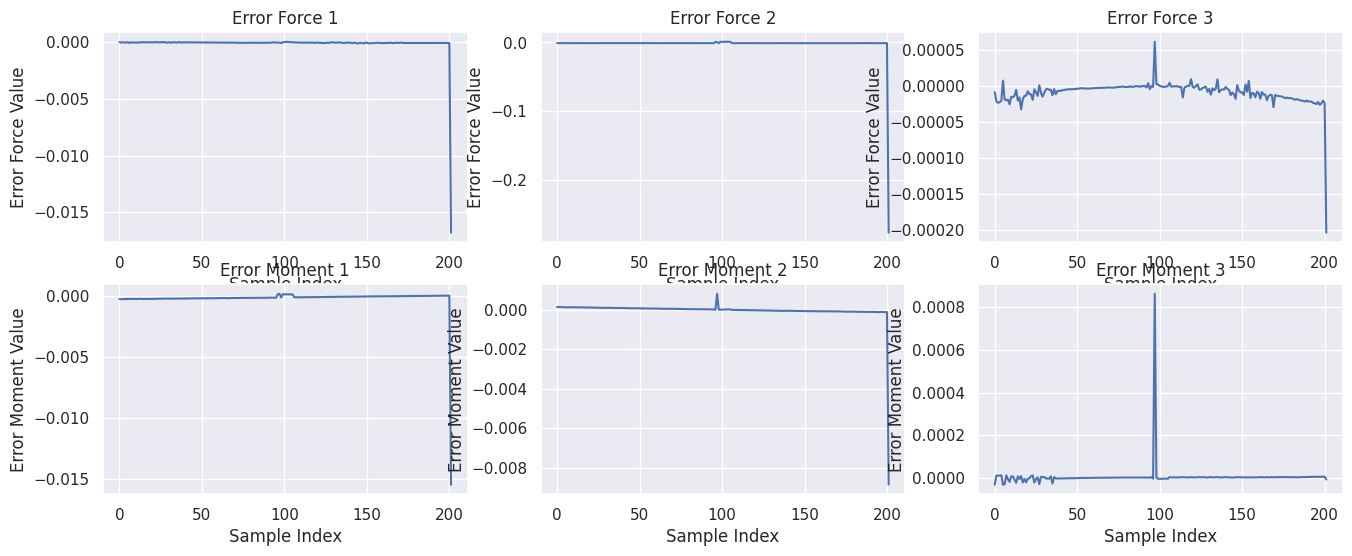

In [250]:
#Checking Constraint violations
N = len(surface_normals_unit)  # or len(surface_normals_unit)
error_eq = jnp.zeros((N, 6))          # Shape (N, 6)
error_eq_norm = jnp.zeros((N,))       # Shape (N,)
error_ineq = jnp.zeros((N, 12))       # Shape (N, 12)
for i in range(len(surface_normals_unit)):
    
    #Equality constraints
    A = jnp.zeros((6,8))
    A = A.at[:3, :4].set(surface_normals_unit[i,:,:])
    A = A.at[:3, 4:8].set(surface_tractions_unit[i,:,:])
    A = A.at[3:6, :4].set(surface_normals_moment[i,:,:])
    A = A.at[3:6, 4:8].set(surface_tractions_moment[i,:,:])
    b = jnp.array([0.0, 0.0, m*g, 0.0, 0.0, 0.0]).reshape(6, 1)
    error = A @ optimal_force[i, :].reshape(8, 1) - b  # Shape (6, 1)
    error_eq = error_eq.at[i, :].set(error.flatten())  # Store as shape (6,)
    error_eq_norm = error_eq_norm.at[i].set(jnp.linalg.norm(error)) 

    #Inequality Constraints
    G = jnp.zeros((12, 8))
    h = jnp.zeros((12, 1))

        # First friction cone constraint: tangential_force_i ≤ μ * normal_force_i
    G = G.at[i, i].set(-coeff_fric)  # Coefficient for normal force
    G = G.at[i, i+4].set(1)          # Coefficient for tangential force
    
    # Second friction cone constraint: -tangential_force_i ≤ μ * normal_force_i
    G = G.at[i+4, i].set(-coeff_fric)  # Coefficient for normal force
    G = G.at[i+4, i+4].set(-1)         # Coefficient for tangential force
    
    # Non-negativity constraint for normal forces: normal_force_i ≥ 0
    G = G.at[i+8, i].set(-1)         # Ensure normal forces are positive
    error_ = G @ optimal_force[i, :].reshape(8, 1) - h  # Shape (12, 1)
    error_ineq = error_ineq.at[i, :].set(error_.flatten())  # Store as shape (12,)

# print("error_eq_norm", error_eq_norm)
print("max(error_eq_norm)", max(error_eq_norm))
print("min(error_eq_norm)", min(error_eq_norm))

# print("Max per timestep:", jnp.max(error_ineq, axis=1))
# print("Min per timestep:", jnp.min(error_ineq, axis=1))

# print("Max per constraint:", jnp.max(error_ineq, axis=0))
# print("Min per constraint:", jnp.min(error_ineq, axis=0))


# Ploting equality errors
samples = np.arange(len(error_eq))
# Create a figure with 8 subplots (2 rows, 4 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
axes = axes.flatten()  # Flatten to easily iterate

for i in range(3):
    axes[i].plot(samples, error_eq[:, i])
    axes[i].set_title(f'Error Force {i+1}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Error Force Value')
    axes[i].grid(True)

for i in range(3,6):
    axes[i].plot(samples, error_eq[:, i])
    axes[i].set_title(f'Error Moment {i-2}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Error Moment Value')
    axes[i].grid(True)

In [251]:
# print("surface_normals_unit", surface_normals_unit)
#print("surface_tractions_unit", surface_tractions_unit)
print("moment_arm", moment_arm)

moment_arm [[[ 0.2559651   0.25605493 -0.25603488 -0.25594509]
  [ 0.28544054 -0.28535947  0.28535989 -0.28544005]
  [ 0.03273946  0.03274407  0.03289596  0.03290056]]

 [[ 0.25568373  0.2563264  -0.25631585 -0.25567328]
  [ 0.2856885  -0.28511104  0.28511212 -0.28568741]
  [ 0.03277407  0.03278393  0.03285612  0.032866  ]]

 [[ 0.25564807  0.25636005 -0.25635156 -0.25563944]
  [ 0.28571854 -0.28508094  0.28507969 -0.28571984]
  [ 0.03279208  0.03278052  0.03285952  0.03284792]]

 ...

 [[ 0.27243517  0.2383405  -0.2386452  -0.27274   ]
  [ 0.26961212 -0.30016848  0.30019418 -0.26958668]
  [ 0.03397919  0.03404391  0.03159534  0.03166016]]

 [[ 0.27258254  0.23813416 -0.23847724 -0.27292564]
  [ 0.2694492  -0.30031011  0.300348   -0.26941147]
  [ 0.03408991  0.03423913  0.03139992  0.03154917]]

 [[ 0.27291015  0.237813   -0.2381157  -0.2732129 ]
  [ 0.26907212 -0.30064705  0.30055747 -0.26916176]
  [ 0.03444721  0.03350648  0.03213273  0.03119206]]]


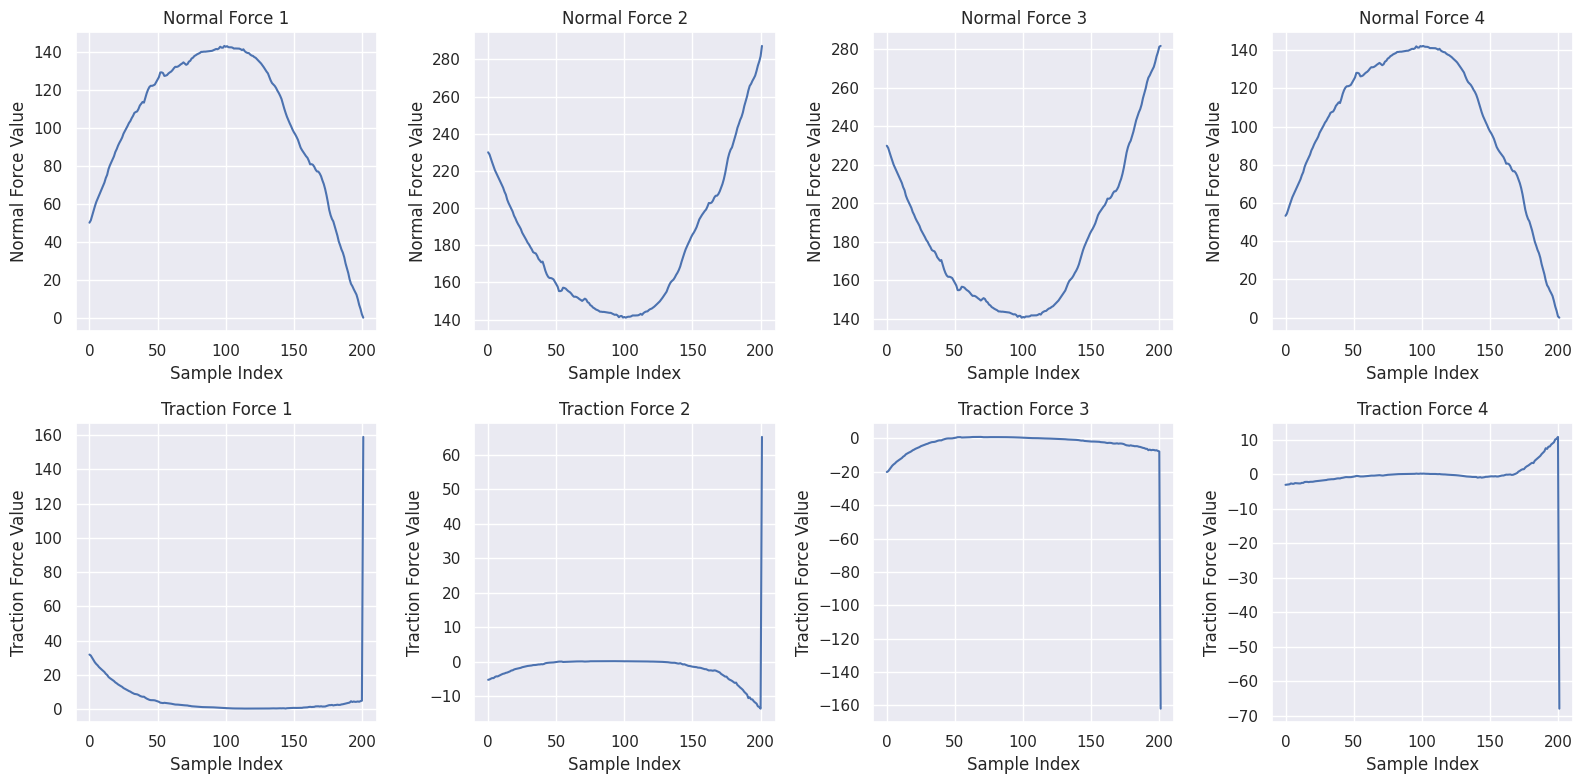

In [252]:


# Ploting obtained optimal forces
samples = np.arange(len(optimal_force))
# Create a figure with 8 subplots (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # Flatten to easily iterate

# Plot each component in a separate subplot
for i in range(4):
    axes[i].plot(samples, optimal_force[:, i])
    axes[i].set_title(f'Normal Force {i+1}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Normal Force Value')
    axes[i].grid(True)

for i in range(4, 8):
    axes[i].plot(samples, optimal_force[:, i])
    axes[i].set_title(f'Traction Force {i-3}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Traction Force Value')
    axes[i].grid(True)

plt.tight_layout()
plt.show()


In [253]:
# Create column labels
columns = [f'Normal_{i+1}' for i in range(4)] + [f'Traction_{i+1}' for i in range(4)]

# Create a DataFrame
force_df = pd.DataFrame(optimal_force, columns=columns)

# Save to CSV
optimal_forces_path = os.path.expanduser(f'~/isaacsim/IsaacLab/optimal_forces_{surface_type}.csv')
force_df.to_csv(optimal_forces_path, index_label='Count')


In [254]:
# print("zc1", zc1)
# print("zc1_", zc1_)

In [ ]:
#Plot path 2D

# Create 2D plot
plt.plot(x, y, marker='o')  # You can change 'o' to other markers or use '-' for lines
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('2D Plot of x vs y')
plt.grid(True)
plt.show()

In [ ]:
# plt.savefig("./figs/stability_comp_traj_2.svg", format="svg",transparent=True)

In [ ]:
# plt.savefig("./figs/stability_comp_res_2.eps")

In [ ]:
# plt.savefig("./figs/stability_tip_comp.eps")

In [ ]:
# plt.savefig("./figs/stability_tip_comp.eps")

In [ ]:
# np.savez("./data/stability_test_2.npz",pcd=pcd,x_init=x_init,y_init=y_init,z_init=z_init,x_fin=x_fin,y_fin=y_fin,z_fin=z_fin,primal_sol_x=primal_sol_x,primal_sol_y=primal_sol_y,
# res=res,x=x,y=y,z=z,res_grad=res_grad,x_cex=x_cem,y_cem=y_cem,grad_vec=grad_vec,lam=lam,p1=p1,p2=p2,p3=p3,p4=p4,primal_sol_x2=primal_sol_x2,primal_sol_y2=primal_sol_y2,
# res2=res2,x2=x2,y2=y2,z2=z2,res_grad2=res_grad2,x_cem2=x_cem2,y_cem2=y_cem2,grad_vec2=grad_vec2,t1=t1,t2=t2,pose=pose,pose2=pose2,psi=psi,
# psi2=psi2 )

In [ ]:
from terrain_plot_pcd import terrain_plot
tplot = terrain_plot()
for i in range(10):
    tplot.plot_terr(x[i],y[i],psi[i],pose[i,:],pcd[:,0],pcd[:,1],pcd[:,2],'k')